# Evaporative Cooling — 3D Box Potential

Semiclassical simulation of evaporative cooling for an ideal gas confined in a
3D box potential, comparing Bose-Einstein, Fermi-Dirac, and Maxwell-Boltzmann
statistics.

The density of states scales as $g(\varepsilon) \propto \varepsilon^{1/2}$, giving
polylogarithm orders $\nu = 3/2$ (particle number) and $\nu = 5/2$ (energy).

**Reference:** Arvizu-Velázquez et al., *Semi-classical evaporative cooling:
classical and quantum distributions*, arXiv (2026).

In [1]:
import numpy as np
import mpmath as mp
import math
import scipy.special as ss
from matplotlib import pyplot as plt
import time

from evap_cooling_utils import (
    ConstantsSI, ConstantsEV,
    g_tilde, g_bar,
    newton_raphson_1var, newton_raphson_2var_fused, newton_raphson_2var_fused_real,
    mb_particle_number, mb_temperature_box, mb_temperature_quadrupole, mb_temperature_oscillator,
    create_result_dict, create_mb_result_dict,
    build_cutoff_schedule, initialize_boson_state, initialize_mb_state,
    run_quantum_evaporation, run_mb_evaporation,
    plot_combined_overview, plot_individual_panels,
)

## 1. Physical Parameters

In [2]:
# Physical constants (SI)
h  = ConstantsSI.h
hb = ConstantsSI.hbar
kB = ConstantsSI.kB
m  = ConstantsSI.m_Na23

# Trap parameters
V  = 6e-9   # Effective volume parameter

# Initial thermodynamic state
N0 = 1e7                   # Initial number of atoms
T0 = 5e-5                  # Initial temperature [K] = 50 μK

## 2. Equation of State

In [3]:
def thermal_wavelength(T):
    """de Broglie thermal wavelength λ = √(h² / 2πmkBT)."""
    return mp.sqrt(h**2 / (2 * mp.pi * m * kB * T))
    #return mp.sqrt(2 * mp.pi * hb**2 / (m * kB * T))

# --- Boson equations for initial μ ---
def N_equation_boson(x):
    lam = thermal_wavelength(T0)
    return (V / lam**3) * mp.polylog(3/2, mp.exp(x)) - N0

def dN_equation_boson(x):
    lam = thermal_wavelength(T0)
    return (V / lam**3) * mp.polylog(1/2, mp.exp(x))

# --- Fermion equations for initial μ ---
def N_equation_fermion(x):
    lam = thermal_wavelength(T0)
    return -(V / lam**3) * mp.polylog(3/2, -mp.exp(x)) - N0

def dN_equation_fermion(x):
    lam = thermal_wavelength(T0)
    return -(V / lam**3) * mp.polylog(1/2, -mp.exp(x))

## 3. Compute Initial Chemical Potentials

In [ ]:
# --- Bosons ---
start = time.time()
alpha_b = newton_raphson_1var(N_equation_boson, dN_equation_boson,
                              -15.5, -15, dx=1e-5)
if alpha_b is None:
    raise RuntimeError("Root not found for boson chemical potential")
mu0_b = alpha_b * kB * T0
E0_b = float((3/2) * N0 * kB * T0 * (
    mp.polylog(5/2, mp.exp(alpha_b)) / mp.polylog(3/2, mp.exp(alpha_b))
))
Omega0_b = -N0 * kB * T0 * (mp.polylog(5/2,  mp.exp(alpha_b)) /
                            mp.polylog(3/2,  mp.exp(alpha_b)))
print(f"Bosons:   α = μ/(kBT) = {alpha_b:.6f},  μ = {mu0_b:.6e},  "
      f"E₀ = {E0_b:.6e} , Ω = {Omega0_b:.6e} [{time.time()-start:.1f}s]")

# --- Fermions ---
start = time.time()
alpha_f = newton_raphson_1var(N_equation_fermion, dN_equation_fermion,
                              -15.5, -15, dx=1e-5)
if alpha_f is None:
    raise RuntimeError("Root not found for fermion chemical potential")
mu0_f = alpha_f * kB * T0
E0_f = float((3/2) * N0 * kB * T0 * (
    mp.polylog(5/2, -mp.exp(alpha_f)) / mp.polylog(3/2, -mp.exp(alpha_f))
))
Omega0_f = -N0 * kB * T0 * (mp.polylog(5/2, -mp.exp(alpha_f)) /
                            mp.polylog(3/2, -mp.exp(alpha_f)))
print(f"Fermions: α = μ/(kBT) = {alpha_f:.6f},  μ = {mu0_f:.6e},  "
      f"E₀ = {E0_f:.6e}, Ω = {Omega0_f:.6e}  [{time.time()-start:.1f}s]")

Bosons:   α = μ/(kBT) = -15.295863,  μ = -1.055911e-26,  E₀ = 1.035486e-20  [2.2s]
Fermions: α = μ/(kBT) = -15.295863,  μ = -1.055911e-26,  E₀ = 1.035486e-20  [2.3s]


## 4. Build Cut-off Schedule & Initialize Data

In [ ]:
Q0      = 5e-4          # 0.5 mK cutoff, matches Fig. 2 in the paper
dQ      = 1e-8          # linear cutoff step (≈ 0.01 µK)
N_STEPS = 10000
dT_nr   = T0 * 1e-12           # ≈ 5e-17 K  (T0 = 5e-5)
dmu_nr  = abs(mu0_b) * 1e-12   # ≈ 1e-38    (mu0_b ≈ -1e-26)
Q_schedule = build_cutoff_schedule(Q0, dQ, N_STEPS)

results_b  = create_result_dict()
results_f  = create_result_dict()
results_mb = create_mb_result_dict()

initialize_boson_state(results_b, N0, T0, mu0_b, Omega0_b)
initialize_boson_state(results_f, N0, T0, mu0_f, Omega0_f)
initialize_mb_state(results_mb, N0, T0)

results_b['Q'] = Q_schedule; results_f['Q'] = Q_schedule; results_mb['Q'] = Q_schedule

## 5. Fused Truncated Distribution Functions

Uses the corrected $\tilde{g}_s(\alpha, \sigma)$ via `mp.nsum` (eq. 36 of paper),
where the summation index $j$ appears inside $\operatorname{erf}(\sqrt{j\sigma})$.

For the 3D box ($\nu = 3$), the recurrences (eqs. 32–33) are:

$$\frac{N_i}{N_{i-1}} = \frac{\tilde{g}_{3/2}(\alpha,\eta)}{g_{3/2}(\alpha)}
  - \frac{2}{\sqrt{\pi}}\,\eta^{1/2}\,\frac{\bar{g}_{1}(\alpha,\eta)}{g_{3/2}(\alpha)}$$

$$\frac{E_i}{E_{i-1}} = \frac{\tilde{g}_{5/2}(\alpha,\eta)}{g_{5/2}(\alpha)}
  - \frac{2}{\sqrt{\pi}}\,\eta^{1/2}\,\frac{\bar{g}_{2}(\alpha,\eta)}{g_{5/2}(\alpha)}
  - \frac{4}{3\sqrt{\pi}}\,\eta^{3/2}\,\frac{\bar{g}_{1}(\alpha,\eta)}{g_{5/2}(\alpha)}$$

In [30]:
def _make_truncated_NE_box(sign):
    """
    Build a fused (N₁, E₁) function for the 3D box.
    sign = +1 for bosons, -1 for fermions.
    """
    def truncated_NE(Ni, Ti, Mui, Ei, Qc):
        eta_c = Qc / Ti
        #eta_c = Qc ** 2 / (Ti)
        alpha = Mui / (kB * Ti)
        sqrt_eta = mp.sqrt(eta_c)
        z_full = sign * mp.exp(alpha)

        # g̃ functions — CORRECT implementation via mp.nsum (eq. 36)
        gt_32 = g_tilde(3/2, alpha, eta_c, sign)    # N: truncated integral
        gt_52 = g_tilde(5/2, alpha, eta_c, sign)    # E: truncated integral

        # Standard polylogs for normalisation
        g32_full = mp.polylog(3/2, z_full)           # N: denominator
        g52_full = mp.polylog(5/2, z_full)           # E: denominator

        # ḡ functions — standard polylog with shifted argument (eq. 35)
        gb_1 = g_bar(1, alpha, eta_c, sign)          # N+E boundary (SHARED)
        gb_2 = g_bar(2, alpha, eta_c, sign)          # E boundary

        # Sign convention: for fermions, g_full = -Li_s(-e^α)
        g32_norm = sign * g32_full
        g52_norm = sign * g52_full

        c1 = (2 / mp.sqrt(mp.pi)) * sqrt_eta
        c2 = (4 / (3 * mp.sqrt(mp.pi))) * eta_c**1.5

        N1 = (gt_32 / g32_norm - c1 * gb_1 / g32_norm) * Ni
        #E1 = (gt_52 / g52_norm - c1 * gb_2 / g52_norm - c2 * gb_1 / g52_norm) * Ei
        E1 = (gt_52 / g52_norm - c1 * gb_2 / g52_norm) * Ei

        return (N1, E1)

    return truncated_NE


truncated_NE_boson_box   = _make_truncated_NE_box(+1)
truncated_NE_fermion_box = _make_truncated_NE_box(-1)

## 6. Newton-Raphson (2-Variable) with Precomputed Polylogs

In [35]:
"""
f_val = sign * (V / lam**3) * g32 - Ni
g_val = (3/2) * Ni * kB * T * (g52 / g32) - Ei
f_y_val = sign * (2 * mp.sqrt(2) * mp.pi**1.5 * V * g12) / (kB * c**1.5 * T)
t1 = (3 * mp.sqrt(2) * h**2 * mp.pi**1.5 * V * g32) / (kB * m * T**2 * c**2.5)
t2 = (2 * mp.sqrt(2) * mu * mp.pi**1.5 * V * g12) / (kB * T**2 * c**1.5)
f_x_val = sign * (t1 - t2)
g_y_val = (3 * Ni / 2) * (1 - g12 * g52 / g32**2)
g_x_val = (3 * Ni / 2) * (-mu / T + mu * g12 * g52 / (T * g32**2) + kB * g52 / g32)
"""

'\nf_val = sign * (V / lam**3) * g32 - Ni\ng_val = (3/2) * Ni * kB * T * (g52 / g32) - Ei\nf_y_val = sign * (2 * mp.sqrt(2) * mp.pi**1.5 * V * g12) / (kB * c**1.5 * T)\nt1 = (3 * mp.sqrt(2) * h**2 * mp.pi**1.5 * V * g32) / (kB * m * T**2 * c**2.5)\nt2 = (2 * mp.sqrt(2) * mu * mp.pi**1.5 * V * g12) / (kB * T**2 * c**1.5)\nf_x_val = sign * (t1 - t2)\ng_y_val = (3 * Ni / 2) * (1 - g12 * g52 / g32**2)\ng_x_val = (3 * Ni / 2) * (-mu / T + mu * g12 * g52 / (T * g32**2) + kB * g52 / g32)\n'

In [32]:
"""" 
f_val = sign * (V / lam**3) * g32 - Ni
            g_val = (3/2) * Ni * kB * T * (g52 / g32) - Ei
            #f_y_val = sign * (2 * mp.sqrt(2) * mp.pi**1.5 * V * g12) / (kB * c**1.5 * T)
            f_y_val = sign * (V / lam ** 3) * (1 / (kB * T)) * g12
            #t1 = (3 * mp.sqrt(2) * h**2 * mp.pi**1.5 * V * g32) / (kB * m * T**2 * c**2.5)
            #t2 = (2 * mp.sqrt(2) * mu * mp.pi**1.5 * V * g12) / (kB * T**2 * c**1.5)
            #f_x_val = sign * (t1 - t2)
            f_x_val = sign * ((2 * mp.pi * m * kB) / h) ** (3/2) * V * (((3 / 2) * T ** (1 / 2) * g32) - ((mu / (kB * T ** (1/2))) * g12))
            g_y_val = (3 * Ni / 2) * (1 - g12 * g52 / g32**2)
            g_x_val = ((3 * Ni * kB) / 2) * ((g52 / g32) + ((mu / (kB *T)) * (-1 + ((g52 * g12) / (g32 ** 2)))))
            return (f_val, g_val, f_x_val, f_y_val, g_x_val, g_y_val)
"""

'" \nf_val = sign * (V / lam**3) * g32 - Ni\n            g_val = (3/2) * Ni * kB * T * (g52 / g32) - Ei\n            #f_y_val = sign * (2 * mp.sqrt(2) * mp.pi**1.5 * V * g12) / (kB * c**1.5 * T)\n            f_y_val = sign * (V / lam ** 3) * (1 / (kB * T)) * g12\n            #t1 = (3 * mp.sqrt(2) * h**2 * mp.pi**1.5 * V * g32) / (kB * m * T**2 * c**2.5)\n            #t2 = (2 * mp.sqrt(2) * mu * mp.pi**1.5 * V * g12) / (kB * T**2 * c**1.5)\n            #f_x_val = sign * (t1 - t2)\n            f_x_val = sign * ((2 * mp.pi * m * kB) / h) ** (3/2) * V * (((3 / 2) * T ** (1 / 2) * g32) - ((mu / (kB * T ** (1/2))) * g12))\n            g_y_val = (3 * Ni / 2) * (1 - g12 * g52 / g32**2)\n            g_x_val = ((3 * Ni * kB) / 2) * ((g52 / g32) + ((mu / (kB *T)) * (-1 + ((g52 * g12) / (g32 ** 2)))))\n            return (f_val, g_val, f_x_val, f_y_val, g_x_val, g_y_val)\n'

In [ ]:
def _make_nr_solver_box(sign):
    def solver(T_init, mu_init, dT, dmu, Ni, Ei):
        def jacobian(T, mu):
            z = sign * mp.exp(mu / (kB * T))
            g12 = mp.polylog(1/2, z)
            g32 = mp.polylog(3/2, z)
            g52 = mp.polylog(5/2, z)
            lam = thermal_wavelength(T)
            #c = h**2 / (kB * m * T)

            f_val = sign * (V / lam**3) * g32 - Ni
            g_val = - Ni * kB * T * (g52 / g32) - Ei
            #f_y_val = sign * (2 * mp.sqrt(2) * mp.pi**1.5 * V * g12) / (kB * c**1.5 * T)
            f_y_val = sign * (V / lam ** 3) * (1 / (kB * T)) * g12
            #t1 = (3 * mp.sqrt(2) * h**2 * mp.pi**1.5 * V * g32) / (kB * m * T**2 * c**2.5)
            #t2 = (2 * mp.sqrt(2) * mu * mp.pi**1.5 * V * g12) / (kB * T**2 * c**1.5)
            #f_x_val = sign * (t1 - t2)
            f_x_val = sign * ((2 * mp.pi * m * kB) / h ** 2) ** (3/2) * V * (((3 / 2) * T ** (1 / 2) * g32) - ((mu / (kB * T ** (1/2))) * g12))
            g_y_val = - Ni * (1 - g12 * g52 / g32**2)
            g_x_val = - (Ni * kB) * ((g52 / g32) + ((mu / (kB *T)) * (-1 + ((g52 * g12) / (g32 ** 2)))))
            return (f_val, g_val, f_x_val, f_y_val, g_x_val, g_y_val)
        return newton_raphson_2var_fused(jacobian, T_init, mu_init, dT, dmu)
    return solver

nr_solver_boson_box   = _make_nr_solver_box(+1)
nr_solver_fermion_box = _make_nr_solver_box(-1)

## 7. Run Evaporation Simulations

In [34]:
print("Running boson evaporation...")
start = time.time()
run_quantum_evaporation(results_b, truncated_NE_boson_box,
                        nr_solver_boson_box, N0, N_STEPS, dT_nr, dmu_nr)
print(f"  Done in {time.time()-start:.1f}s")

print("Running fermion evaporation...")
start = time.time()
run_quantum_evaporation(results_f, truncated_NE_fermion_box,
                        nr_solver_fermion_box, N0, N_STEPS, dT_nr, dmu_nr)
print(f"  Done in {time.time()-start:.1f}s")

print("Running Maxwell-Boltzmann evaporation...")
start = time.time()
run_mb_evaporation(results_mb, mb_particle_number, mb_temperature_box, N0, N_STEPS)
print(f"  Done in {time.time()-start:.1f}s")

Running boson evaporation...


TypeError: cannot create mpf from mpc(real='-0.096940803111473559', imag='-6.0390432581273306')

## 8. Results

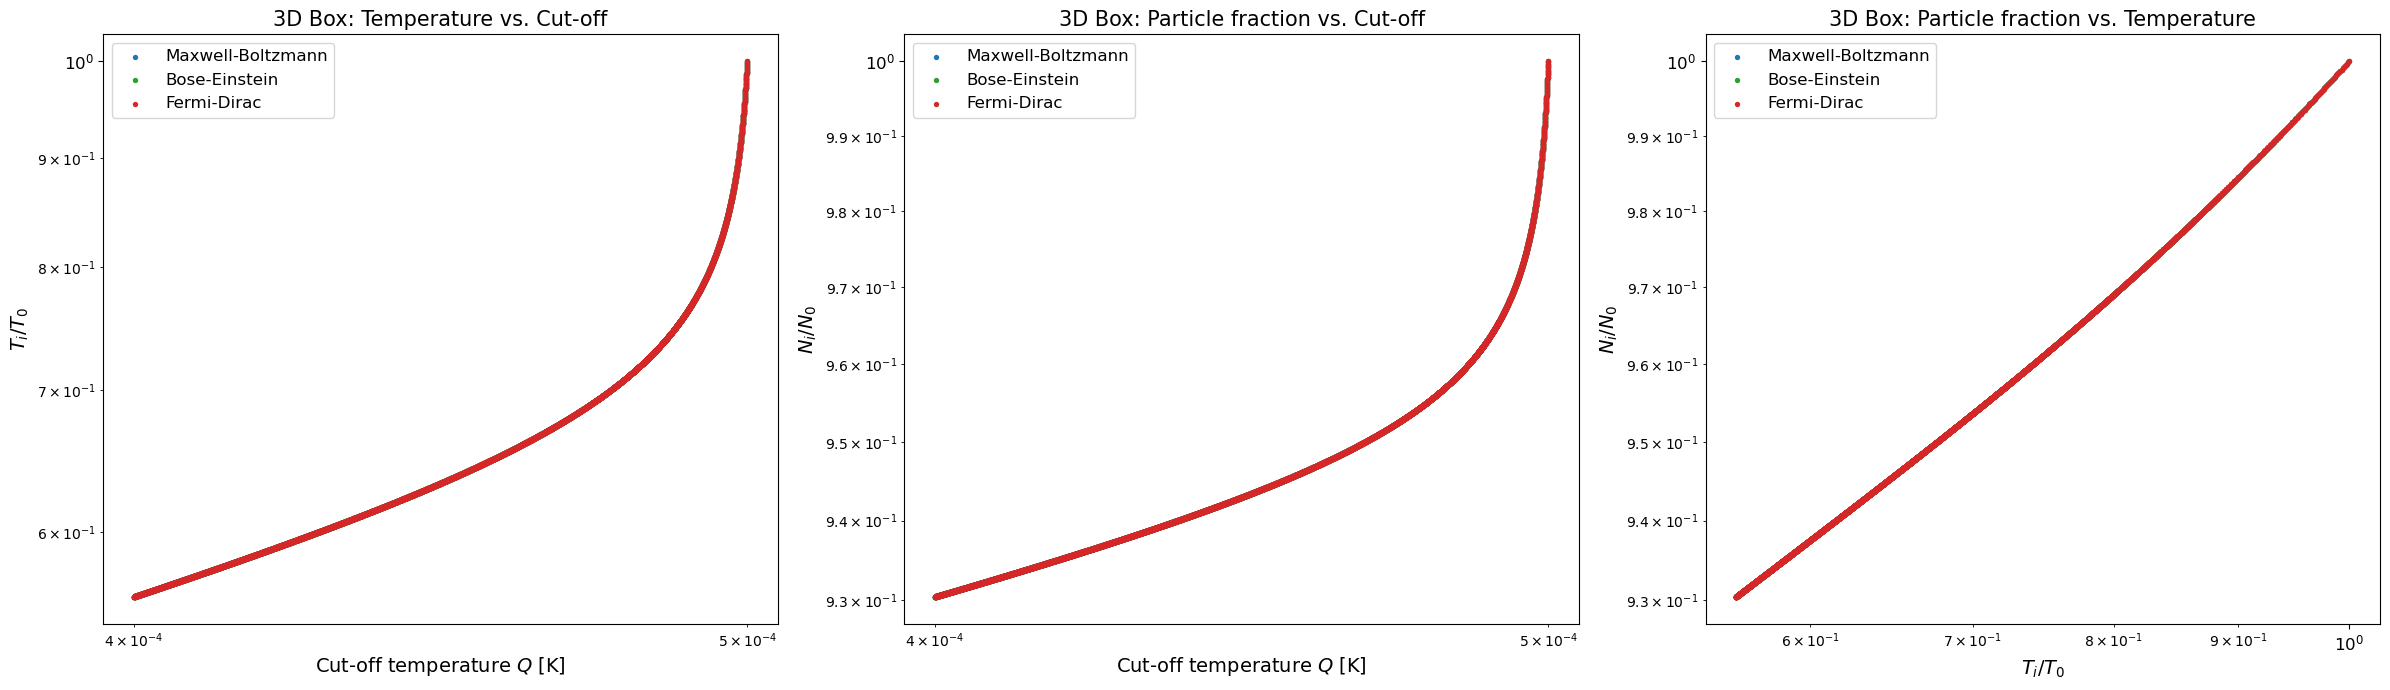

In [ ]:
fig = plot_combined_overview(results_b, results_f, results_mb, "3D Box")
plt.show()

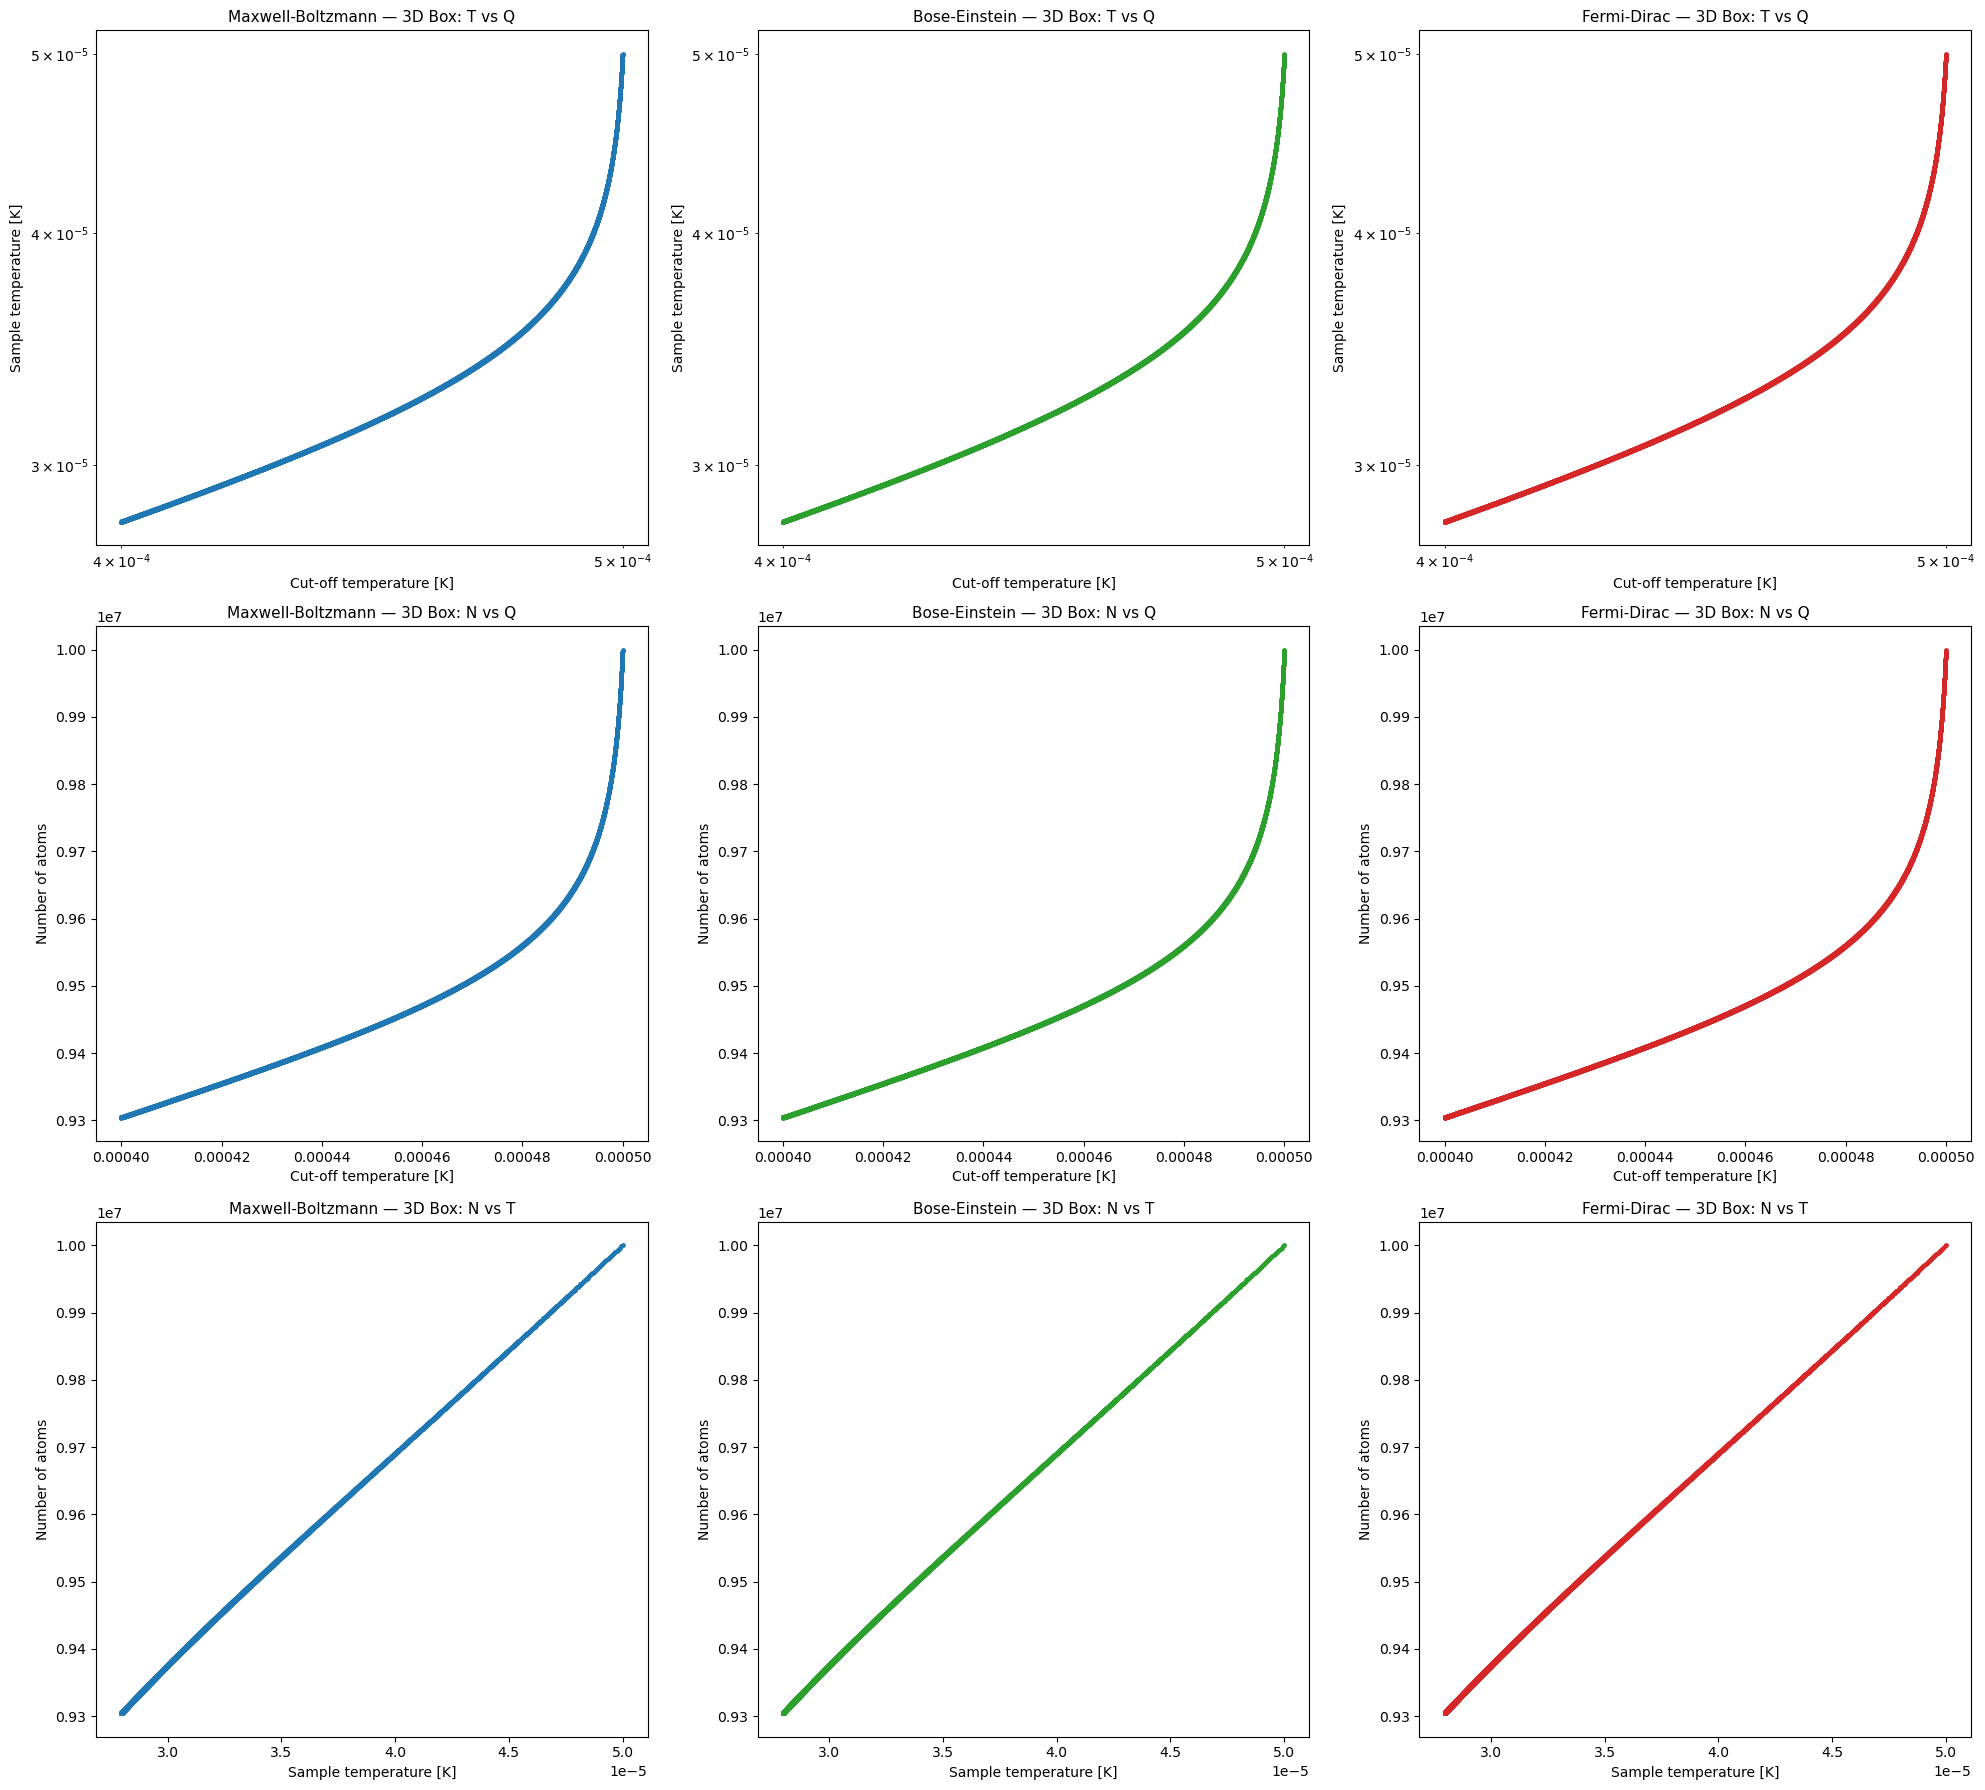

In [ ]:
fig = plot_individual_panels(results_b, results_f, results_mb, "3D Box")
plt.show()